# Agent 13 — Reporting

**What this notebook does:**  
Generates all the charts and tables needed for the presentation slides and the one-page factsheet.

**How to present this to investors:**  
> *Our reporting agent automatically generates the portfolio factsheet, benchmark comparison charts, ESG profile, and sector allocation — all from the same underlying data, ensuring consistency between what we show and what we calculated.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
from datetime import date

TODAY = str(date.today())
REPORT_DIR = "../outputs/reports"

# Load portfolio
port_files = sorted(glob.glob("../outputs/portfolio/final_portfolio_*.csv"))
univ_files = sorted(glob.glob("../outputs/portfolio/universe_scores_*.csv"))

if not port_files:
    raise FileNotFoundError("Run notebook 04 first.")

portfolio = pd.read_csv(port_files[-1])
universe  = pd.read_csv(univ_files[-1])

print(f"Portfolio: {len(portfolio)} holdings")
print(f"Universe:  {len(universe)} companies")

Portfolio: 20 holdings
Universe:  70 companies


## Chart 1 — Portfolio weights (horizontal bar chart)

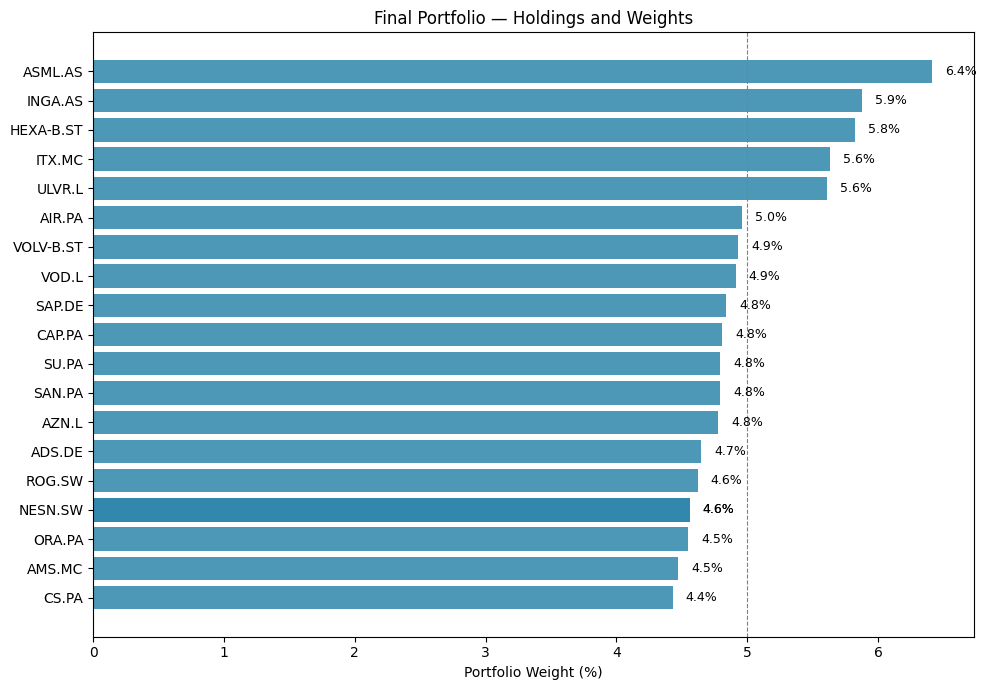

Chart 1 saved.


In [2]:
TICKER_COL = "ticker"

fig, ax = plt.subplots(figsize=(10, 7))
sorted_port = portfolio.sort_values("weight")

bars = ax.barh(sorted_port[TICKER_COL], sorted_port["weight"] * 100, color="#2E86AB", alpha=0.85)
ax.set_xlabel("Portfolio Weight (%)")
ax.set_title("Final Portfolio — Holdings and Weights")
ax.axvline(5, color="grey", linestyle="--", linewidth=0.8, label="5% line")

for bar, val in zip(bars, sorted_port["weight"] * 100):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/portfolio_weights.png", dpi=150)
plt.show()
print("Chart 1 saved.")

## Chart 2 — ESG Score: Portfolio vs. Universe

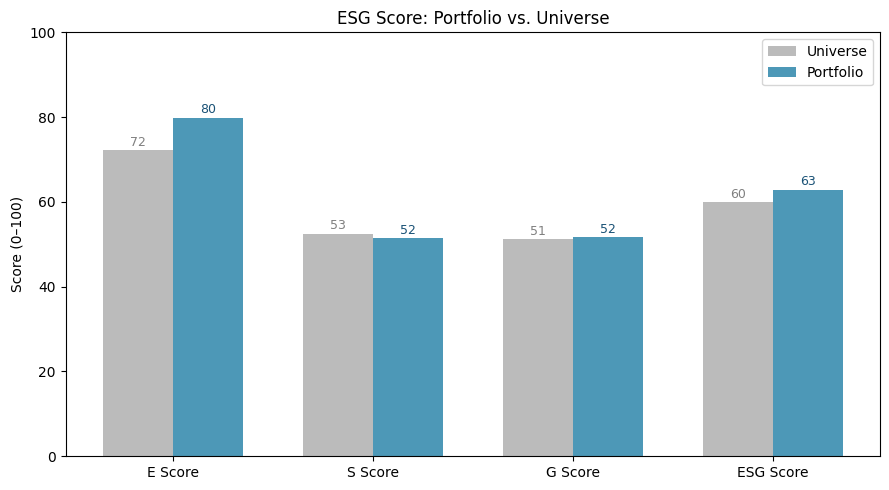

Chart 2 saved.


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = ["E Score", "S Score", "G Score", "ESG Score"]
port_vals  = [portfolio["E_score"].mean(), portfolio["S_score"].mean(),
              portfolio["G_score"].mean(), portfolio["ESG_score"].mean()]
univ_vals  = [universe["E_score"].mean(), universe["S_score"].mean(),
              universe["G_score"].mean(), universe["ESG_score"].mean()]

x = np.arange(len(categories))
w = 0.35

ax.bar(x - w/2, univ_vals, w, label="Universe", color="#AAAAAA", alpha=0.8)
ax.bar(x + w/2, port_vals, w, label="Portfolio", color="#2E86AB", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Score (0–100)")
ax.set_title("ESG Score: Portfolio vs. Universe")
ax.set_ylim(0, 100)
ax.legend()

for xi, (uv, pv) in enumerate(zip(univ_vals, port_vals)):
    ax.text(xi - w/2, uv + 1, f"{uv:.0f}", ha="center", fontsize=9, color="grey")
    ax.text(xi + w/2, pv + 1, f"{pv:.0f}", ha="center", fontsize=9, color="#1a5276")

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/esg_comparison.png", dpi=150)
plt.show()
print("Chart 2 saved.")

## Chart 3 — Sector allocation (pie chart)

In [4]:
# === ACTION REQUIRED ===
# Set the column name that contains sector information
SECTOR_COL = "sector"  # or "bics_sector" — check your master dataset column names

if SECTOR_COL in portfolio.columns:
    sector_weights = portfolio.groupby(SECTOR_COL)["weight"].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        sector_weights,
        labels=sector_weights.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=plt.cm.Set3.colors
    )
    ax.set_title("Portfolio — Sector Allocation")
    plt.tight_layout()
    plt.savefig(f"{REPORT_DIR}/sector_allocation.png", dpi=150)
    plt.show()
    print("Chart 3 saved.")
    print(f"\nSectors represented: {len(sector_weights)} (minimum required: 5)")
else:
    print(f"Column '{SECTOR_COL}' not found. Columns available: {list(portfolio.columns)}")

Column 'sector' not found. Columns available: ['ticker', 'E_score', 'S_score', 'G_score', 'ESG_score', 'data_vintage', 'annual_return_pct', 'annual_volatility_pct', 'sharpe_ratio', 'max_drawdown_pct', 'data_vintage_fin', 'sharpe_score', 'composite_score', 'rank', 'weight_raw', 'weight']


## Table — Top 5 Holdings Summary

This goes directly onto the factsheet and presentation Slide 7.

In [5]:
top5 = portfolio.nlargest(5, "weight")[
    [TICKER_COL, "weight", "ESG_score", "sharpe_ratio", "composite_score"]
].copy()

top5["weight"] = top5["weight"].map("{:.1%}".format)
top5.columns = ["Ticker", "Weight", "ESG Score", "Sharpe Ratio", "Composite Score"]
print("Top 5 Holdings:")
top5

Top 5 Holdings:


,Ticker,Weight,ESG Score,Sharpe Ratio,Composite Score
0,ASML.AS,6.4%,56.48,1.907,73.89
1,INGA.AS,5.9%,55.04,1.655,67.73
2,HEXA-B.ST,5.8%,59.20,1.506,67.10
3,ITX.MC,5.6%,71.53,1.049,64.90
4,ULVR.L,5.6%,66.06,1.194,64.66


## Print: Factsheet Summary Block

Copy this text block into your one-page factsheet document.

In [6]:
weighted_esg    = (portfolio["ESG_score"] * portfolio["weight"]).sum()
weighted_sharpe = (portfolio["sharpe_ratio"] * portfolio["weight"]).sum()
universe_esg    = universe["ESG_score"].mean()

print("=" * 55)
print("   PORTFOLIO FACTSHEET — KEY METRICS")
print("=" * 55)
print(f"  Date:                  {TODAY}")
print(f"  Number of Holdings:    {len(portfolio)}")
print(f"  Weighted ESG Score:    {weighted_esg:.1f} / 100")
print(f"  Universe ESG Score:    {universe_esg:.1f} / 100")
print(f"  ESG Improvement:       +{weighted_esg - universe_esg:.1f} points")
print(f"  Weighted Sharpe Ratio: {weighted_sharpe:.2f}")
print(f"  Max Single Weight:     {portfolio['weight'].max():.1%}")
print(f"  Exclusions Applied:    see exclusions.csv")
print("=" * 55)

   PORTFOLIO FACTSHEET — KEY METRICS
  Date:                  2026-05-06
  Number of Holdings:    20
  Weighted ESG Score:    62.7 / 100
  Universe ESG Score:    60.0 / 100
  ESG Improvement:       +2.7 points
  Weighted Sharpe Ratio: 0.99
  Max Single Weight:     6.4%
  Exclusions Applied:    see exclusions.csv


## ✅ All done!

All charts saved to `outputs/reports/`. Your pipeline is complete:

| Notebook | Agent | Status |
|----------|-------|--------|
| 01_data_ingestion | Data Ingestion Agent | ✅ |
| 02_financial_analysis | Financial Analysis Agent | ✅ |
| 03_esg_scoring | ESG Scoring Agent | ✅ |
| 04_portfolio_construction | Portfolio Construction Agent | ✅ |
| 05_reporting | Reporting Agent | ✅ |

**Remaining work (outside notebooks):**
- Claude Projects RAG → greenwashing 8-Test (RAG Operator)
- n8n.cloud orchestration diagram (Pipeline Operator)
- Written report sections (all)